In [1]:
import numpy as np
from pyscf import gto, scf, mcscf, ao2mo
from qchem.utils import  (
    MoleculeData,
    get_hf_gse_from_mol,
    one_electron_integral_transform,
    two_electron_integral_transform,
    DMDMWorkflow,
    CalculationMode
    )

from dmdm.interface import DMDM
import qrunch as qc


qc.register_license_file("/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/license_fm.txt")

/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/core/public_api.py:254: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  module = cast(_ImportCallable, _original_import)(name, globals, locals, fromlist, level)
/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/src/qchem/utils.py:10: UserWarning: The module 'qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator' is not part of the public API of 'qrunch'. Its interface may change without notice.
The module was imported from qchem.utils.
  from qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator import ReducedDensityMatrixCalculator
/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/common/register_license.py:125: UserWarning: A license file already exists at user config path /home/flemming/.local/share/qrunch/license.txt. Will NOT

converged SCF energy = -227.890625669143
E(RMP2) = -228.242206541955  E_corr = -0.351580872812541
E(SCS-RMP2) = -228.250310871104  E_corr = -0.359685201961003

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -227.948015368438  E(CI) = -6.43743465066734  S^2 = 0.0000000
CASCI state   1  E = -227.767589815668  E(CI) = -6.25700909789714  S^2 = 2.0000000
CASCI state   2  E = -227.712486519522  E(CI) = -6.20190580175117  S^2 = 2.0000000
CASCI state   3  E = -227.712485793452  E(CI) = -6.20190507568117  S^2 = 2.0000000
CASCI state   4  E = -227.688433968548  E(CI) = -6.17785325077716  S^2 = 0.0000000
CASCI state   5  E = -227.624568460159  E(CI) = -6.11398774238791  S^2 = 2.0000000
idx, max(abs(grad active)): 7 2.9591814430686538e-15
Smallest Hessian eigenvalue: (0.1891696423540094+0j)
Smallest diagonal element in the metric: 0.9200896414659743
Done with CASCI computations...

  Inactive: 

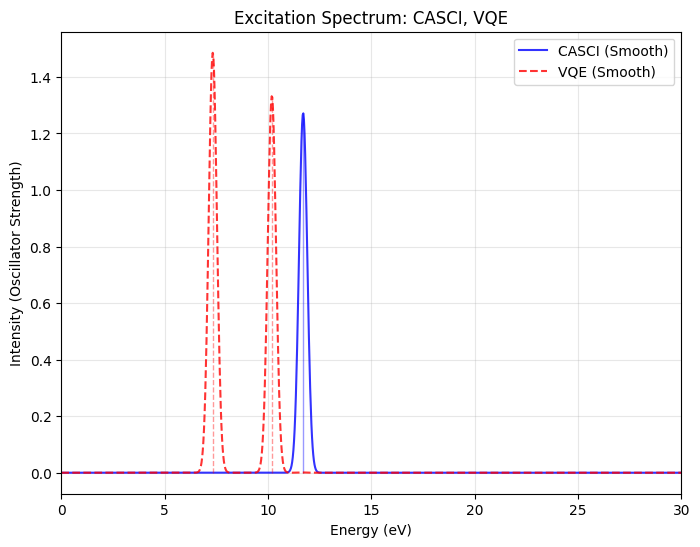

{'casci': {'exc_energies_ev': array([ 0.        ,  7.3788264 , 10.20944516, 11.53336739, 11.54706987,
         11.70272419]),
  'oscillator_strengths': array([0.00000000e+00, 2.87323784e-08, 1.10433480e-07, 1.14675925e-27,
         1.85298841e-05, 1.27235889e+00]),
  'total_energies': array([-227.94801537, -227.76758982, -227.71248652, -227.71248579,
         -227.68843397, -227.62456846]),
  'e_cas': array([-6.43743465, -6.2570091 , -6.2019058 , -6.20190508, -6.17785325,
         -6.11398774]),
  'dmdm_obj': <dmdm.interface.DMDM at 0x7f1a887a5ed0>},
 'vqe': {'exc_energies_ev': array([ 0.        ,  7.33141532, 10.19056335, 11.521281  , 11.53504519,
         11.68050987]),
  'oscillator_strengths': array([0.00000000e+00, 1.48550688e+00, 1.33335772e+00, 7.76392740e-18,
         1.85299864e-05, 9.39288314e-04]),
  'dmdm_obj': <dmdm.interface.DMDM at 0x7f1a8d2573d0>}}

In [2]:
benzene_molecule = [
    ('C',  1.396,  0.000,  0.000),
    ('C',  0.698,  1.209,  0.000),
    ('C', -0.698,  1.209,  0.000),
    ('C', -1.396,  0.000,  0.000),
    ('C', -0.698, -1.209,  0.000),
    ('C',  0.698, -1.209,  0.000),
    ('H',  2.483,  0.000,  0.000),
    ('H',  1.242,  2.151,  0.000),
    ('H', -1.242,  2.151,  0.000),
    ('H', -2.483,  0.000,  0.000),
    ('H', -1.242, -2.151,  0.000),
    ('H',  1.242, -2.151,  0.000),
]


workflow = DMDMWorkflow(
    basis='sto-3g',
    molecule=benzene_molecule,
    num_active_orbitals=6,
    num_active_electrons=6,
    num_states=6,
    mode=CalculationMode.BOTH,
    vqe_max_iterations=1000,
    verbose=1
)



# Simple H2O example

# workflow = DMDMWorkflow(
#     basis="aug-cc-pVDZ",
#     molecule=MoleculeData.molecules["H2O"]["coords"], # String key for qchem MoleculeData
#     num_active_orbitals=4,
#     num_active_electrons=4,
#     num_states=5,
#     mode=CalculationMode.BOTH,
#     license_file_path=path_license,
#     vqe_max_iterations=500
# )

# VQE only
# workflow.run_quantum_vqe()

# Runs both, then plots comparison
workflow.run_comparison(plot=True)
# workflow.run_quantum_vqe()
# workflow.plot_spectrum(show_vqe=True, show_casci=False)

converged SCF energy = -76.0390921843414
E(RMP2) = -76.2624063714749  E_corr = -0.223314187133453
E(SCS-RMP2) = -76.2576615002881  E_corr = -0.21856931594665

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -76.0391045346113  E(CI) = -6.10740202695838  S^2 = 0.0000000
CASCI state   1  E = -75.6827978529692  E(CI) = -5.75109534531624  S^2 = 2.0000000
CASCI state   2  E = -75.6785939654531  E(CI) = -5.74689145780010  S^2 = 0.0000000
CASCI state   3  E = -75.6256954909973  E(CI) = -5.69399298334432  S^2 = 2.0000000
CASCI state   4  E = -75.6248585975570  E(CI) = -5.69315608990405  S^2 = 0.0000000
idx, max(abs(grad active)): 1 3.285504600743182e-15
Smallest Hessian eigenvalue: (0.3593415606568727+0j)
Smallest diagonal element in the metric: 0.9999846697444696
  Inactive: 3, Active: 4, Virtual: 34
idx, max(abs(grad active)): 18 1.7349918355474836e-07
Smallest Hessian eigenvalue: (0.359341

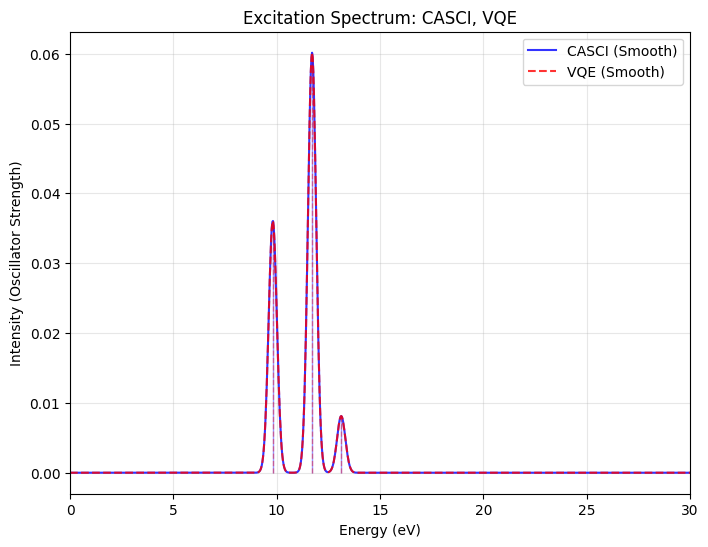

{'casci': {'exc_energies_ev': array([ 0.        ,  9.80999772, 11.27246235, 11.71135652, 13.12180316]),
  'oscillator_strengths': array([0.00000000e+00, 3.60913562e-02, 1.80253615e-28, 6.01369884e-02,
         8.11688515e-03]),
  'total_energies': array([-76.03910453, -75.68279785, -75.67859397, -75.62569549,
         -75.6248586 ]),
  'e_cas': array([-6.10740203, -5.75109535, -5.74689146, -5.69399298, -5.69315609]),
  'dmdm_obj': <dmdm.interface.DMDM at 0x7f1a78cc0450>},
 'vqe': {'exc_energies_ev': array([ 0.        ,  9.80999771, 11.27246231, 11.71135649, 13.12180315]),
  'oscillator_strengths': array([0.00000000e+00, 3.60913566e-02, 9.18668555e-26, 6.01369766e-02,
         8.11688571e-03]),
  'dmdm_obj': <dmdm.interface.DMDM at 0x7f1a791eb190>}}

In [4]:
# Simple H2O example

workflow = DMDMWorkflow(
    basis="aug-cc-pVDZ",
    molecule=MoleculeData.molecules["H2O"]["coords"], # String key for qchem MoleculeData
    num_active_orbitals=4,
    num_active_electrons=4,
    num_states=5,
    mode=CalculationMode.BOTH,
    vqe_max_iterations=1000
)

# VQE only
# workflow.run_quantum_vqe()

# Runs both, then plots comparison
workflow.run_comparison(plot=True)

In [ ]:
print("check abs difference: \n")
abs(workflow._casci_results["exc_energies_ev"] - workflow._vqe_results["exc_energies_ev"])